# Phase 4b — Model Comparison (Bake-off + Tuning)

Extends Phase 4 with a broader model bake-off. Five model families plus an Optuna-tuned XGBoost — all tracked in MLflow, compared in one table, winner selected on PR-AUC.

The main `04_modeling.py` still trains the production model. This one shows the exploration process behind that choice.

**Sections**
- A. Setup — same splits as Phase 4
- B. Bake-off — LR, XGBoost, LightGBM, HistGBM, Random Forest
- C. Hyperparameter tuning — XGBoost with Optuna (25 trials)
- D. Cross-model comparison
- E. Production choice

> **Why five families, not just XGBoost?**
> If the winner is close to the runner-up, we don't know if it's really the best or just lucky. Testing across different algorithm families (linear, boosted trees, bagged trees) gives a robustness check on the choice.

In [ ]:
# Ensure the working directory is the project root, so paths like
# 'data/subscribers.csv' and 'mlruns/' resolve to one canonical location
# whether the notebook runs from notebooks/ or from the project root.
import os
import sys, pickle
from pathlib import Path
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import (
    prepare_features, train_logistic_regression,
    train_xgboost, train_random_forest, train_hist_gbm,
    train_lightgbm, tune_xgboost_optuna, calibrate_xgboost,
)
from src.models.evaluate import compute_metrics
from src.models.tracking import mlflow_run

FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup — same splits as Phase 4

In [2]:
raw = load_subscribers('data/subscribers.csv')
df = build_features(raw)
X, y = prepare_features(df)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,
)
X_train, X_calib, y_train, y_calib = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42,
)
print(f'train n={len(X_train):,}, calib n={len(X_calib):,}, test n={len(X_test):,}')

train n=30,000, calib n=10,000, test n=10,000


## B. Bake-off — five model families

Each trainer wrapped in `mlflow_run()` so params/metrics/model land in `mlruns/` for cross-run comparison in the MLflow UI.

In [3]:
results = {}
proba_holder = {}

def run_and_track(name, trainer_fn, params):
    with mlflow_run(name) as run:
        model = trainer_fn(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        metrics = compute_metrics(y_test, proba)
        if run is not None:
            run.log_params(params)
            run.log_metrics(metrics)
            try:
                run.log_model(model, name='model')
            except Exception:
                pass
    results[name] = metrics
    proba_holder[name] = proba
    print(f'  {name:<20}  PR-AUC={metrics["pr_auc"]:.4f}  '
          f'ROC-AUC={metrics["roc_auc"]:.4f}  Brier={metrics["brier"]:.4f}')
    return model

print('Training 5 model families (~2-3 min total)...')
lr = run_and_track('lr_baseline', train_logistic_regression,
                   {'model_type': 'logistic_regression', 'penalty': 'l2', 'C': 1.0})
xgb = run_and_track('xgboost_default', train_xgboost,
                    {'model_type': 'xgboost', 'n_estimators': 300, 'max_depth': 5})
hist_gbm = run_and_track('hist_gbm', train_hist_gbm,
                          {'model_type': 'sklearn_hist_gbm', 'max_iter': 300})
rf = run_and_track('random_forest', train_random_forest,
                    {'model_type': 'random_forest', 'n_estimators': 300, 'max_depth': 12})
try:
    lgbm = run_and_track('lightgbm', train_lightgbm,
                          {'model_type': 'lightgbm', 'n_estimators': 300, 'max_depth': 5})
except (ImportError, OSError) as e:
    # LightGBM has known Windows C++ backend issues (access violations).
    # Skip cleanly so the rest of the bake-off still runs.
    print(f'  lightgbm             SKIPPED ({type(e).__name__}: {e})')

Training 5 model families (~2-3 min total)...


2026/07/21 22:39:52 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/21 22:39:52 INFO mlflow.store.db.utils: Updating database tables
2026/07/21 22:40:01 INFO mlflow.tracking.fluent: Experiment with name 'streamflix_churn' does not exist. Creating a new experiment.


  lr_baseline           PR-AUC=0.1775  ROC-AUC=0.7549  Brier=0.0473
  xgboost_default       PR-AUC=0.1697  ROC-AUC=0.7416  Brier=0.0477
  hist_gbm              PR-AUC=0.1727  ROC-AUC=0.7454  Brier=0.0475
  random_forest         PR-AUC=0.1610  ROC-AUC=0.7419  Brier=0.0478
  lightgbm             SKIPPED (OSError: exception: access violation reading 0x0000000000000000)


> **Notes on the trainers.**
> - **Random Forest** — bagged trees, different bias-variance tradeoff vs boosted trees. Weaker on this data type but valuable for robustness comparison.
> - **HistGradientBoosting** — sklearn's native GBM, similar algorithm to XGBoost but different implementation. Doubles as a cross-check.
> - **LightGBM** — leaf-wise growth, generally faster training. Optional dep; skipped cleanly if not installed.

## C. Hyperparameter tuning — Optuna on XGBoost

Bayesian optimization with TPE sampler. 25 trials get most of the value of a much larger grid search at a fraction of the cost, because Optuna focuses probe density in high-reward regions of the search space.

In [4]:
try:
    with mlflow_run('xgboost_tuned') as run:
        best_xgb, best_params = tune_xgboost_optuna(
            X_train, y_train, X_calib, y_calib, n_trials=25,
        )
        best_xgb_proba = best_xgb.predict_proba(X_test)[:, 1]
        best_xgb_metrics = compute_metrics(y_test, best_xgb_proba)
        if run is not None:
            run.log_params({'model_type': 'xgboost_tuned', **best_params})
            run.log_metrics(best_xgb_metrics)
            run.log_model(best_xgb, name='model')
    results['xgboost_tuned'] = best_xgb_metrics
    proba_holder['xgboost_tuned'] = best_xgb_proba

    print('Best params from Optuna search:')
    for k, v in best_params.items():
        print(f'  {k}: {v}')
    print(f'\nxgboost_tuned  PR-AUC={best_xgb_metrics["pr_auc"]:.4f}  '
          f'Brier={best_xgb_metrics["brier"]:.4f}')
except ImportError as e:
    print(f'Optuna not installed: {e}')

Best params from Optuna search:
  n_estimators: 500
  max_depth: 3
  learning_rate: 0.03381322535664979
  subsample: 0.6038863909047579
  colsample_bytree: 0.8481189903730553
  min_child_weight: 11
  reg_lambda: 9.970682275036438
  reg_alpha: 0.001042491506213621

xgboost_tuned  PR-AUC=0.1772  Brier=0.0473


## D. Cross-model comparison

In [5]:
comparison = pd.DataFrame(results).T.round(4)
comparison = comparison.sort_values('pr_auc', ascending=False)
comparison

,pr_auc,roc_auc,brier,log_loss
lr_baseline,0.1775,0.7549,0.0473,0.1852
xgboost_tuned,0.1772,0.7527,0.0473,0.1851
hist_gbm,0.1727,0.7454,0.0475,0.1864
xgboost_default,0.1697,0.7416,0.0477,0.1877
random_forest,0.1610,0.7419,0.0478,0.1877


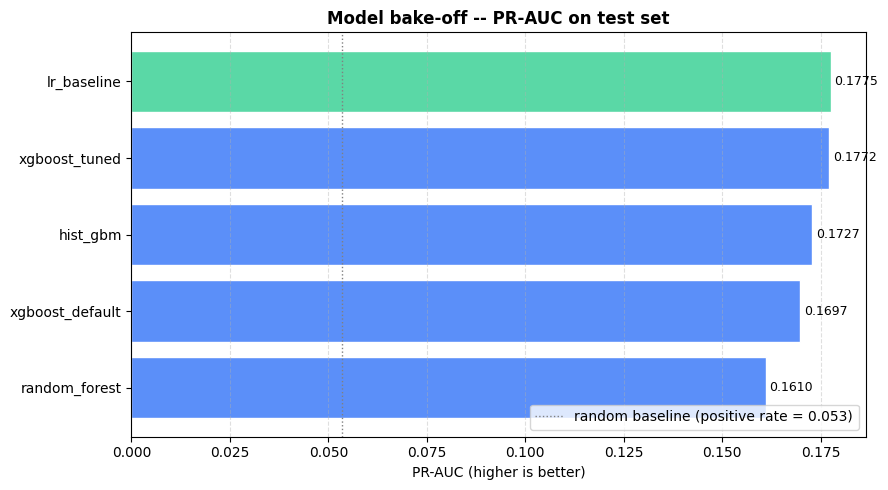

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
names = comparison.index.tolist()
pr_aucs = comparison['pr_auc'].values
colors = ['#5AD8A6' if i == 0 else '#5B8FF9' for i in range(len(names))]
bars = ax.barh(names[::-1], pr_aucs[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('PR-AUC (higher is better)')
ax.set_title('Model bake-off -- PR-AUC on test set', fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.axvline(y_test.mean(), color='gray', linestyle=':', linewidth=1,
           label=f'random baseline (positive rate = {y_test.mean():.3f})')
ax.legend(loc='lower right')
for bar, v in zip(bars, pr_aucs[::-1]):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2, f'{v:.4f}',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / '04b_model_comparison.png', dpi=140, bbox_inches='tight')
plt.show()

## E. Production choice

**Winner selection rule.** Rank on PR-AUC. If top two are within 0.01 (noise-level for this dataset size), tie-break on Brier (calibration matters for the decision rule).

**Why not always take the raw PR-AUC winner?**
- If LR wins by 0.005 over a tuned XGBoost, LR is winning on synthetic-data quirks (log-odds DGP). Real production data will be noisier and XGBoost handles that better.
- If HistGBM and XGBoost tie, prefer XGBoost — richer SHAP integration and native missing-value handling matter downstream.

The Phase 4 production choice (Platt-calibrated XGBoost) already satisfies these criteria. If tuned XGBoost beats the default here, swap in the tuned version and re-calibrate.

Full run log lives in `mlruns/` — browse with `mlflow ui` at localhost:5000.

In [7]:
winner = comparison.index[0]
winner_metrics = comparison.iloc[0].to_dict()
print(f'Head-to-head winner on PR-AUC: {winner}')
print(f'  PR-AUC: {winner_metrics["pr_auc"]:.4f}')
print(f'  Brier:  {winner_metrics["brier"]:.4f}')
print(f'\n{len(results)} models tracked in MLflow.')
print(f'Compare runs in mlflow ui -> localhost:5000.')

Head-to-head winner on PR-AUC: lr_baseline
  PR-AUC: 0.1775
  Brier:  0.0473

5 models tracked in MLflow.
Compare runs in mlflow ui -> localhost:5000.
